In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
industry = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Industry": industry,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Industry: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [5]:
missing = pd.DataFrame({
    "Missing Values": {
        name: df.isnull().sum().sum()
        for name, df in datasets.items()
    }
})

missing

,Missing Values
Fund Master,0
NAV History,0
AUM,0
SIP,12
Category,0
Industry,0
Performance,0
Transactions,0
Portfolio,0
Benchmark,0


In [6]:
print("Fund Master")
display(fund_master.head())

print("NAV History")
display(nav_history.head())

print("Performance")
display(performance.head())

print("Benchmark")
display(benchmark.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


Benchmark


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
# Sort NAV history

nav_history = nav_history.sort_values(["amfi_code", "date"])

# Daily Return = Today's NAV / Yesterday's NAV - 1

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


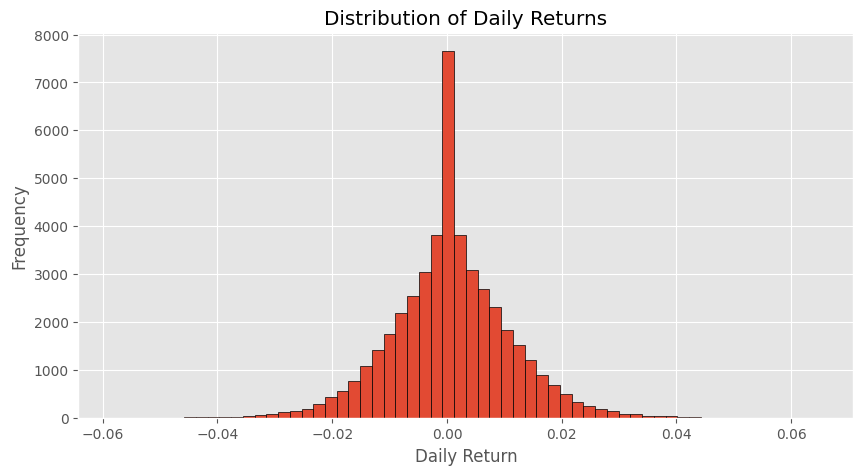

In [8]:
plt.figure(figsize=(10,5))

nav_history["daily_return"].dropna().hist(
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [9]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [10]:
# Latest NAV date

latest_date = nav_history["date"].max()

latest_date

Timestamp('2026-05-29 00:00:00')

In [11]:
def calculate_cagr(df, years):
    """
    Calculate CAGR for each mutual fund over the specified number of years.
    """

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    results = []

    for amfi, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        start_rows = group[group["date"] >= start_date]
        end_rows = group[group["date"] <= end_date]

        if len(start_rows) == 0 or len(end_rows) == 0:
            continue

        start_nav = start_rows.iloc[0]["nav"]
        end_nav = end_rows.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append({
            "amfi_code": amfi,
            f"CAGR_{years}Y": round(cagr, 2)
        })

    return pd.DataFrame(results)

In [12]:
cagr_1 = calculate_cagr(nav_history, 1)
cagr_3 = calculate_cagr(nav_history, 3)
cagr_5 = calculate_cagr(nav_history, 5)

cagr = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [13]:
cagr_comparison = (
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ]
    .merge(cagr, on="amfi_code")
)

cagr_comparison.head()

,amfi_code,scheme_name,fund_house,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.44,30.46,22.38
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,5.71,16.27,18.71
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,82.78,26.67,28.03
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,13.95,-1.34,1.81
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,5.52,5.84,5.16


In [14]:
cagr_comparison.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,CAGR_1Y,CAGR_3Y,CAGR_5Y
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,22.26,35.11,24.45
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,20.36,34.00,26.80
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,13.06,32.49,20.23
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.23,32.44,26.07
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.60,31.78,28.38
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.44,30.46,22.38
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,26.66,29.58,26.74
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.75,29.18,27.63
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.92,28.97,20.44
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.14,27.00,27.92


In [15]:
# Annual Risk-Free Rate (RBI Repo Proxy)

RISK_FREE_RATE = 0.065
DAILY_RF = RISK_FREE_RATE / 252

print("Daily Risk-Free Rate:", DAILY_RF)

Daily Risk-Free Rate: 0.00025793650793650796


In [16]:
sharpe_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - RISK_FREE_RATE)
        / annual_volatility
    )

    sharpe_results.append({
        "amfi_code": amfi,
        "Sharpe_Ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.2015
1,100025,-0.5671
2,100033,1.0937
3,101206,1.0272
4,101207,0.1627


In [17]:
sharpe_rank = (
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ]
    .merge(sharpe_df, on="amfi_code")
    .sort_values(
        "Sharpe_Ratio",
        ascending=False
    )
    .reset_index(drop=True)
)

sharpe_rank.head(10)

,amfi_code,scheme_name,fund_house,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.4483
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.3067
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.2349
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.2083
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.1801
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,1.1321
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.0937
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.0817
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,1.0272
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.0265


In [18]:
sortino_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < DAILY_RF]

    downside_std = downside_returns.std() * np.sqrt(252)

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (
            (annual_return - RISK_FREE_RATE)
            / downside_std
        )

    sortino_results.append({
        "amfi_code": amfi,
        "Sortino_Ratio": round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.3482
1,100025,-0.9154
2,100033,1.8238
3,101206,1.7856
4,101207,0.2746


In [19]:
risk_metrics = (
    sharpe_df.merge(
        sortino_df,
        on="amfi_code"
    )
)

risk_metrics = (
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ]
    .merge(
        risk_metrics,
        on="amfi_code"
    )
)

risk_metrics.head()

,amfi_code,scheme_name,fund_house,Sharpe_Ratio,Sortino_Ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.2083,2.1040
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.9533,1.6040
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.9453,1.6612
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-0.0572,-0.0941
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,-0.2266,-0.3665


In [20]:
# Sort benchmark data
benchmark = benchmark.sort_values(["index_name", "date"])

# Use one benchmark as market proxy
market = benchmark[benchmark["index_name"] == benchmark["index_name"].iloc[0]].copy()

# Calculate daily market returns
market["market_return"] = market["close_value"].pct_change()

market = market[["date", "market_return"]].dropna()

market.head()

,date,market_return
3451,2022-01-04,0.019783
3452,2022-01-05,0.008620
3453,2022-01-06,0.002332
3454,2022-01-07,-0.038726
3455,2022-01-10,0.006049


In [21]:
alpha_beta = []

for amfi, group in nav_history.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        market,
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        merged["market_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": amfi,
        "Alpha": round(alpha * 252, 4),
        "Beta": round(beta, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.0331,0.0100
1,100025,0.0442,-0.0052
2,100033,0.2637,0.0319
3,101206,0.2190,-0.0166
4,101207,0.1197,-0.0486


In [22]:
alpha_beta_df = (
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ]
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
)

alpha_beta_df.head()

,amfi_code,scheme_name,fund_house,Alpha,Beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.2377,-0.0256
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.2074,-0.0363
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.3151,-0.0476
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.0478,0.0113
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,0.0558,0.0010


In [23]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv generated successfully!")

alpha_beta.csv generated successfully!


In [24]:
# ---------------------------------
# Maximum Drawdown
# ---------------------------------

drawdown_results = []

for amfi, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["Running_Max"] = group["nav"].cummax()

    group["Drawdown"] = (
        group["nav"] - group["Running_Max"]
    ) / group["Running_Max"]

    max_drawdown = group["Drawdown"].min()

    drawdown_results.append({
        "amfi_code": amfi,
        "Maximum_Drawdown": round(max_drawdown * 100, 2)
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Maximum_Drawdown
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [25]:
# ---------------------------------
# Fund Scorecard
# ---------------------------------

scorecard = (
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "return_3yr_pct",
            "sharpe_ratio"
        ]
    ]
    .merge(
        alpha_beta_df[
            ["amfi_code", "Alpha", "Beta"]
        ],
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

In [26]:
scorecard["Score"] = (
    scorecard["return_3yr_pct"].rank(pct=True) * 40 +
    scorecard["sharpe_ratio"].rank(pct=True) * 30 +
    scorecard["Alpha"].rank(pct=True) * 20 +
    (-scorecard["Maximum_Drawdown"]).rank(pct=True) * 10
)

scorecard["Score"] = scorecard["Score"].round(2)

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,Alpha,Beta,Maximum_Drawdown,Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,0.94,0.3151,-0.0476,-28.71,86.25
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08,0.95,0.2981,-0.0210,-18.19,76.75
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,0.98,0.2720,0.0022,-12.97,73.00
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23,0.96,0.0802,-0.0060,-24.00,68.25
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.06,0.2677,0.0109,-11.27,68.12


In [27]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv generated successfully!")

fund_scorecard.csv generated successfully!


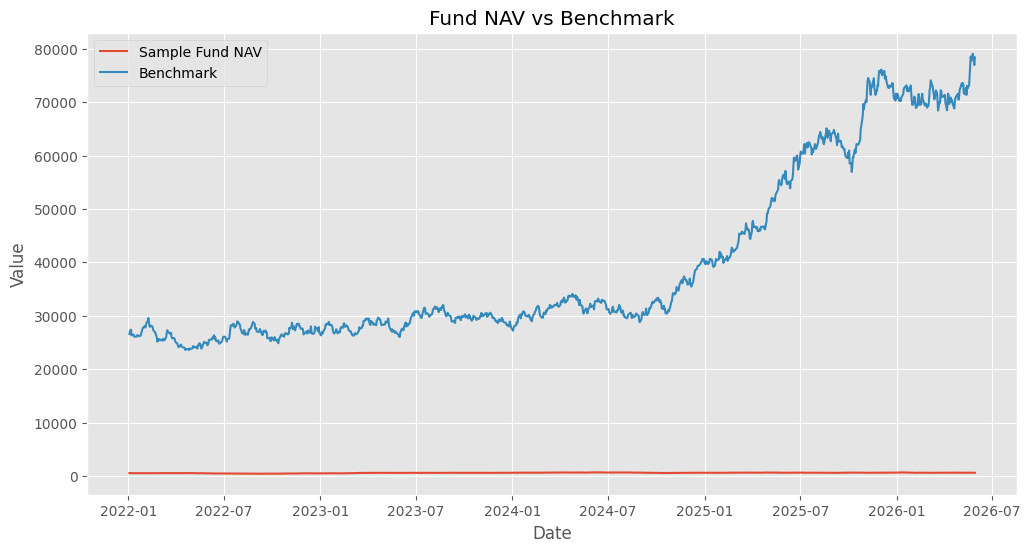

In [28]:
plt.figure(figsize=(12,6))

# First fund
sample_fund = nav_history[
    nav_history["amfi_code"] ==
    nav_history["amfi_code"].iloc[0]
]

plt.plot(
    sample_fund["date"],
    sample_fund["nav"],
    label="Sample Fund NAV"
)

plt.plot(
    benchmark[
        benchmark["index_name"] ==
        benchmark["index_name"].iloc[0]
    ]["date"],
    benchmark[
        benchmark["index_name"] ==
        benchmark["index_name"].iloc[0]
    ]["close_value"],
    label="Benchmark"
)

plt.title("Fund NAV vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()